---
## Generate House Data

In [51]:
import numpy as np
import pandas as pd
df = pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [52]:
X = df[["Avg. Area Income", "Avg. Area Number of Bedrooms"]]
y = df[['Price']]
print(X.head())
print(y.head())
print(f"Features: square feet and bedrooms | X shape: {X.shape}")
print(f"Target: price | y shape: {y.shape}")

   Avg. Area Income  Avg. Area Number of Bedrooms
0      79545.458574                          4.09
1      79248.642455                          3.09
2      61287.067179                          5.13
3      63345.240046                          3.26
4      59982.197226                          4.23
          Price
0  1.059034e+06
1  1.505891e+06
2  1.058988e+06
3  1.260617e+06
4  6.309435e+05
Features: square feet and bedrooms | X shape: (5000, 2)
Target: price | y shape: (5000, 1)


---
## Create Training, Validation, and Test Sets

Training data fits the models, validation data chooses K, and test data is used once for final evaluation.

In [53]:
import numpy
import scipy
import sklearn

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 1.24.4
SciPy: 1.9.1
Scikit-learn: 1.0.2


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_remaining, y_remaining, test_size=0.5, random_state=42
)

print(f"Training: {len(X_train)} | Validation: {len(X_validation)} | Test: {len(X_test)}")

Training: 3000 | Validation: 1000 | Test: 1000


---
## Why Scaling Matters

Square feet and bedrooms have very different numeric ranges. We compare the same KNN model before and after scaling.

In [55]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# Create a KNN regression model that uses the 5 nearest neighbors.
knn_without_scaling = KNeighborsRegressor(n_neighbors=5)

# Train the KNN model using the training features and their actual house prices.
knn_without_scaling.fit(X_train, y_train)

# Use the trained model to predict house prices for the validation data.
prediction_without_scaling = knn_without_scaling.predict(X_validation)

# R² measures how well the model explains the variation in the actual target values; closer to 1 means better performance.
print(f"Validation R² without scaling: {r2_score(y_validation, prediction_without_scaling):.3f}")

Validation R² without scaling: 0.268


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline that first scales the data and then applies KNN regression.
scaled_knn = Pipeline([
    ("scaler", StandardScaler()), # Standardize each feature using the training data's mean and standard deviation.    
    ("knn", KNeighborsRegressor(n_neighbors=5)) # Create a KNN regression model that uses the 5 nearest neighbors.
])

# Train the pipeline on the training data; scaling is fitted only on X_train.
scaled_knn.fit(X_train, y_train)

# Scale the validation features using the fitted scaler and predict their house prices.
prediction_with_scaling = scaled_knn.predict(X_validation)

# Calculate and display the R² score to measure the model's performance on validation data.
print(f"Validation R² with scaling: {r2_score(y_validation, prediction_with_scaling):.3f}")

Validation R² with scaling: 0.307


---
## Choose K Using Validation MSE

Fit each candidate on the training set and choose the K with the lowest validation MSE. The test set remains untouched.

In [57]:
# Import Mean Squared Error (MSE) to measure the model's prediction error.
from sklearn.metrics import mean_squared_error

# Create K values from 1 to 30 to find the best number of neighbors.
k_values = list(range(1, 31))

# Create an empty list to store the validation MSE for each K value.
validation_mse = []

for k in k_values:

    # Create a pipeline that scales the features and then applies KNN regression.
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    # Train the model using the training data.
    model.fit(X_train, y_train)

    # Predict house prices for the validation dataset.
    validation_prediction = model.predict(X_validation)

    # Calculate and store the validation MSE for the current K value.
    validation_mse.append(mean_squared_error(y_validation, validation_prediction))

# Select the K value that produces the lowest validation MSE.
best_k = k_values[np.argmin(validation_mse)]

# Display the selected K value.
print(f"Selected K: {best_k}")

# Display the lowest validation MSE achieved among all tested K values.
print(f"Lowest validation MSE: {min(validation_mse):,.0f}")

Selected K: 30
Lowest validation MSE: 71,630,852,799


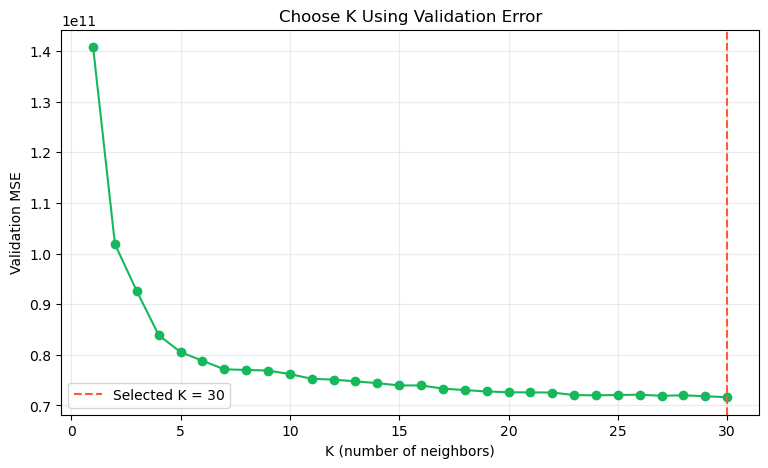

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(k_values, validation_mse, color="#16B85C", marker="o")
plt.axvline(best_k, color="#FF5A36", linestyle="--", label=f"Selected K = {best_k}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Validation MSE")
plt.title("Choose K Using Validation Error")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

---
## Fit the Final Pipeline and Evaluate Once

K is now locked. Combine the training and validation sets, refit the Pipeline, and evaluate it once on the untouched test set.

In [ ]:
# Combine the training and validation features to create the final training dataset.
X_final_train = np.vstack([X_train, X_validation])

# Combine the training and validation target values (house prices).
y_final_train = np.concatenate([y_train, y_validation])

# Create the final pipeline with feature scaling followed by KNN regression.
final_pipeline = Pipeline([
    
    ("scaler", StandardScaler()),# Standardize all features before applying KNN.    # Create the KNN model using the best K value selected during validation.
    ("knn", KNeighborsRegressor(n_neighbors=best_k))
])

# Train the final pipeline using both training and validation data.
final_pipeline.fit(X_final_train, y_final_train)

# Use the final trained model to predict prices for the unseen test data.
test_prediction = final_pipeline.predict(X_test)

# Display the K value selected during the validation process.
print(f"Final K: {best_k}")

# Calculate and display the Mean Squared Error (MSE) on the test data.
print(f"Test MSE: {mean_squared_error(y_test, test_prediction):,.0f}")

# Calculate and display the R² score on the test data.
print(f"Test R²: {r2_score(y_test, test_prediction):.3f}")

Final K: 30
Test MSE: 69,571,824,662
Test R²: 0.448


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


---
## Save and Load the Fitted Pipeline

The fitted StandardScaler and KNN model are saved together in one file.

---
## Create the Prediction Function

The function receives user values, calls the fitted Pipeline, and returns a readable result.

---
## Visualize the Selected Neighbors

Because the Pipeline scales the features before KNN, the plot uses standardized feature values. The highlighted labels show the known prices that are averaged for the prediction.

---
## Build One Gradio Interface

Run the installation cell only when Gradio is not already available.